In [48]:
from aoe2mapgenerator.src.units.wallgenerators.perlin import PerlinGenerator
from AoE2ScenarioParser.datasets.players import PlayerId
from AoE2ScenarioParser.datasets.units import UnitInfo
from AoE2ScenarioParser.datasets.buildings import BuildingInfo
from AoE2ScenarioParser.datasets.other import OtherInfo
from AoE2ScenarioParser.datasets.terrains import TerrainId
from src.common.enums.enum import (
    MapLayerType,
    ObjectSize,
    GateType,
    TemplateTypes,
    ObjectRotation,
    YamlReplacementKeywords,
    CheckPlacementReturnTypes,
)

from src.scenario.scenario import Scenario
import numpy as np
import random
from src.common.constants.constants import (
    DEFAULT_EMPTY_VALUE,
    BASE_SCENE_DIR_LINUX,
    BASE_SCENARIO_NAME,
    TEMPLATE_DIR_LINUX,
)
from src.common.constants.default_objects import (
    GHOST_OBJECT_DISPLACEMENT,
)
from src.common.enums.enum import GateType
import multiprocessing as mp
from src.map.map import Map
import os
from src.triggers.triggers import TriggerManager
import inspect
import ast
import json
from enum import Enum
from src.units.wallgenerators.voronoi import VoronoiGenerator
from AoE2ScenarioParser.scenarios.aoe2_de_scenario import AoE2DEScenario
from src.units.placers.statictemplate import TemplateCreator
from src.units.placers.group_placer import GroupPlacerManager
from src.units.placers.point_management.point_manager import (
    PointCollection,
)
from src.testing import awesome_function
from src.map.map_object import MapObject
from src.units.placers.point_management.point_selector import (
    PointSelector,
)
from src.visualizer.visualizer import Visualizer
from src.units.placers.gate_placer import GatePlacer
from src.units.placers.wall_placer import WallPlacer
from src.map.map_manager import MapManager
from src.units.placers.placer_configs import *
from src.units.placers.placer_configs import PlaceGroupsConfig
import dataclasses
import json

In [49]:
aoe2map = MapManager(100)

In [50]:
n = 50
aoe2map.point_manager.add_point_collection(
    "base", [(i, j) for i in range(n) for j in range(n)]
)
collection = aoe2map.point_manager.get_point_collection("base")
collection.remove_points([(i, j) for i in range(49) for j in range(10)])

In [51]:
config = VoronoiGeneratorConfig(
    point_collection=aoe2map.point_manager.get_point_collection("base"),
    interpoint_distance=25,
    map_layer_type=MapLayerType.ZONE,
)
aoe2map.voronoi_generator.generate_voronoi_cells(config)

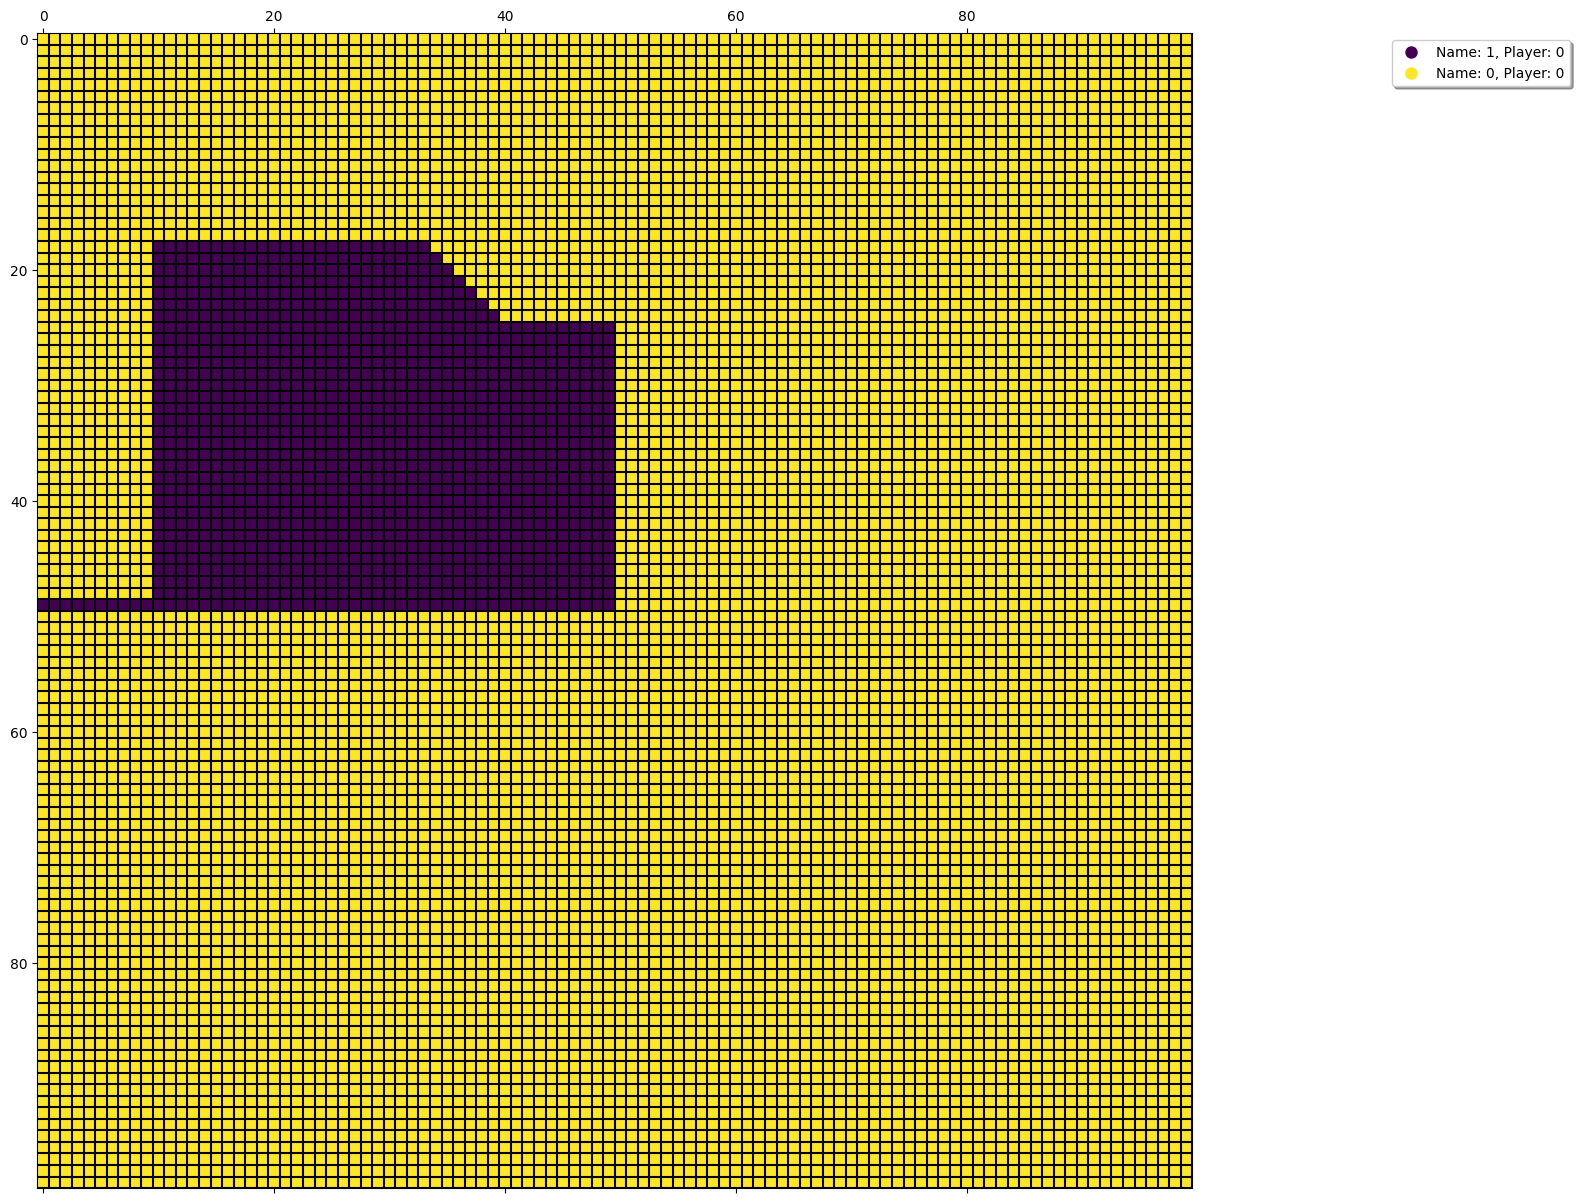

In [52]:
config = VisualizeMapConfig(
    map_layer_type=MapLayerType.ZONE,
)
aoe2map.visualize_map(config)